In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy as sc
import seaborn as sns
import itertools
import math

!pip install pyproj
!pip install adjustText


from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator

from scipy.stats import gaussian_kde
from scipy import stats
from scipy.stats import linregress
from scipy.stats import shapiro, ks_2samp, levene, ttest_ind, mannwhitneyu
from collections import OrderedDict


from pyproj import Transformer

from adjustText import adjust_text

In [9]:
df2 = pd.read_csv("Profiles.csv")
df3 = pd.read_csv("XSection.csv")

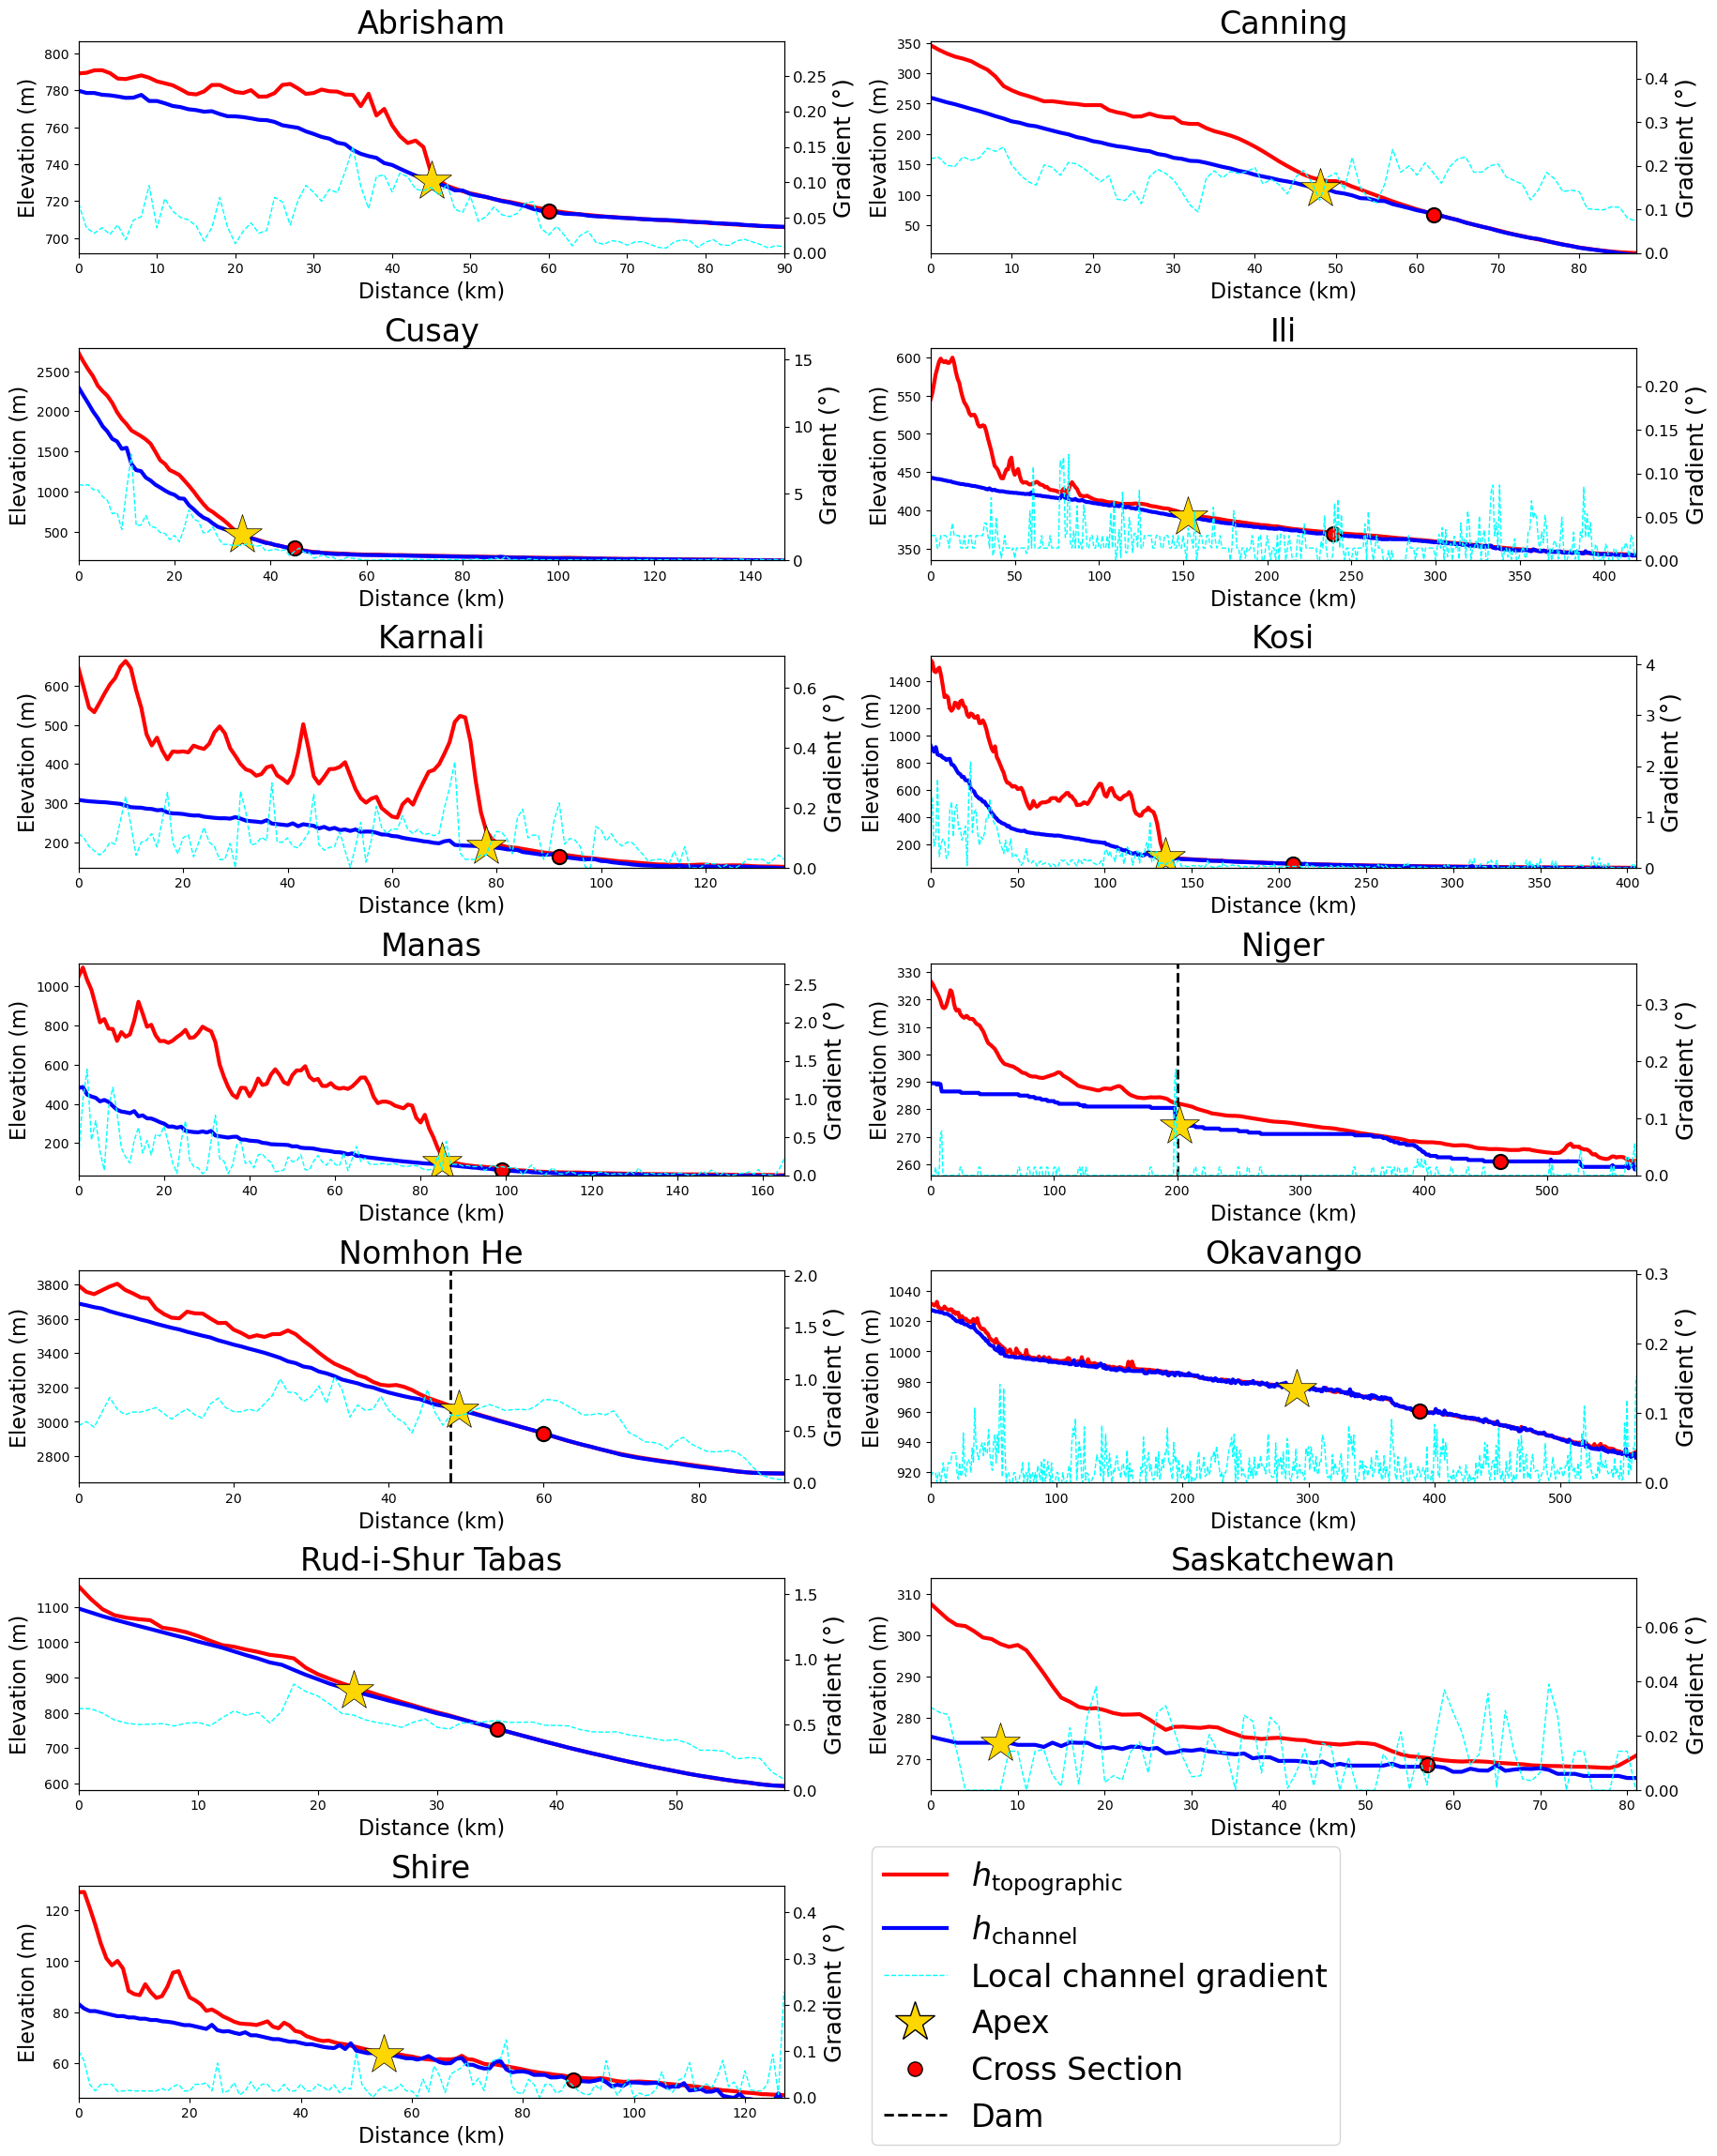

In [10]:
# -------------------------------
# Strip column names
df2.columns = df2.columns.str.strip()

# List of unique fans
fan_list = df2['Fan'].unique()

# Optional: manual Dam markers per fan
dam_dict = {
    'Nomhon He': [48],
    'Niger': [200]
}

# Smoothing window sizes
window_topo = 1
window_river = 1
window_slope = 1

# -------------------------------
# Subplot layout: 2 columns, dynamic rows
ncols = 2
nrows = int(np.ceil(len(fan_list) / ncols))
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(20, 3.4 * nrows))
axes = axes.flatten()

# Prepare legend handles for global legend (match actual plot sizes)
apex_marker_size = 1000  # same as s in scatter
cross_marker_size = 120  # same as s in scatter

apex_legend = plt.Line2D([0], [0], marker='*', color='gold', markerfacecolor='gold',
                         markersize=np.sqrt(apex_marker_size), markeredgecolor='black', linewidth=0)
cross_legend = plt.Line2D([0], [0], marker='o', color='red', markerfacecolor='red',
                          markersize=np.sqrt(cross_marker_size), markeredgecolor='black', linewidth=0)
dam_legend = plt.Line2D([0], [0], color='black', linestyle='--', linewidth=2, label='Dam')

# -------------------------------
# Loop through each fan
for i, fan_name in enumerate(fan_list):
    ax1 = axes[i]

    # Filter and sort
    df_fan = df2[df2['Fan'] == fan_name].copy().sort_values("Distance")

    # Interpolate missing values
    df_fan['Mean Elevation'] = df_fan['Mean Elevation'].interpolate(method='linear')
    df_fan['Topo_elev_smooth'] = df_fan['Mean Elevation'].rolling(window=window_topo, center=True).mean()
    df_fan['River_elev_smooth'] = df_fan['River Elevation'].rolling(window=window_river, center=True).mean()

    # River slope
    gradient_river = np.gradient(df_fan['River Elevation'], df_fan['Distance'] * 1000)
    df_fan['River_slope_deg'] = np.degrees(np.arctan(np.abs(gradient_river)))
    df_fan['River_slope_deg_smooth'] = df_fan['River_slope_deg'].rolling(window=window_slope, center=True).mean()

    # Plot elevations
    topo_line, = ax1.plot(df_fan['Distance'], df_fan['Topo_elev_smooth'],
                          color='red', linewidth=3, zorder=1)
    river_line, = ax1.plot(df_fan['Distance'], df_fan['River_elev_smooth'],
                           color='blue', linewidth=3, zorder=2)

    # Vertical dashed lines for Dams
    for dam in dam_dict.get(fan_name, []):
        ax1.axvline(x=dam, color='black', linestyle='--', linewidth=2, zorder=3)

    # Apex marker (yellow star)
    if 'Apex' in df_fan.columns:
        apex_data = df_fan[df_fan['Apex'] == 'Apex']
        if not apex_data.empty:
            ax1.scatter(apex_data['Distance'], df_fan.loc[apex_data.index, 'River_elev_smooth'],
                        marker='*', s=apex_marker_size, color='gold', edgecolor='black', linewidths=0.5, zorder=5)

    # Cross Section marker (red circle)
    cross_data = df_fan[df_fan['Cross Section'] == 'Cross Section']
    if not cross_data.empty:
        ax1.scatter(cross_data['Distance'], df_fan.loc[cross_data.index, 'River_elev_smooth'],
                    marker='o', s=cross_marker_size, color='red', edgecolor='black', linewidths=1.5, zorder=6)

    # Dynamic y-limits for elevation
    ymin, ymax = df_fan['Topo_elev_smooth'].min(), df_fan['Topo_elev_smooth'].max()
    ax1.set_ylim(0.98 * ymin, 1.02 * ymax)

    # Force x-axis to go exactly from first to last data point
    ax1.set_xlim(df_fan['Distance'].min(), df_fan['Distance'].max())
    ax1.margins(x=0)  # remove extra horizontal padding

    ax1.set_xlabel('Distance (km)', fontsize=16)
    ax1.set_ylabel('Elevation (m)', fontsize=16)
    ax1.tick_params(axis='both', labelsize=10)
    ax1.set_title(fan_name, fontsize=24)

    # Secondary axis: slope
    ax2 = ax1.twinx()
    slope_line, = ax2.plot(df_fan['Distance'], df_fan['River_slope_deg_smooth'],
                           color='cyan', linestyle='--', linewidth=1, zorder=1)
    ax2.set_ylabel('Gradient (°)', fontsize=18)
    ax2.tick_params(axis='y', labelsize=12)
    max_slope = df_fan['River_slope_deg_smooth'].max()
    ax2.set_ylim(0, 2 * max_slope if max_slope > 0 else 0.5)

# Hide unused subplots
for j in range(len(fan_list), len(axes)):
    axes[j].axis('off')

# -------------------------------
# Single global legend at lower-right (updated labels)
# -------------------------------
fig.legend(
    [topo_line, river_line, slope_line, apex_legend, cross_legend, dam_legend],
    [r"$h_{\mathrm{topographic}}$", r"$h_{\mathrm{channel}}$", "Local channel gradient", "Apex", "Cross Section", "Dam"],
    loc="lower right",
    fontsize=24,
    ncol=1,
    bbox_to_anchor=(0.725, 0.0)
)

plt.tight_layout(rect=[0, 0, 0.92, 0.97])
plt.show()


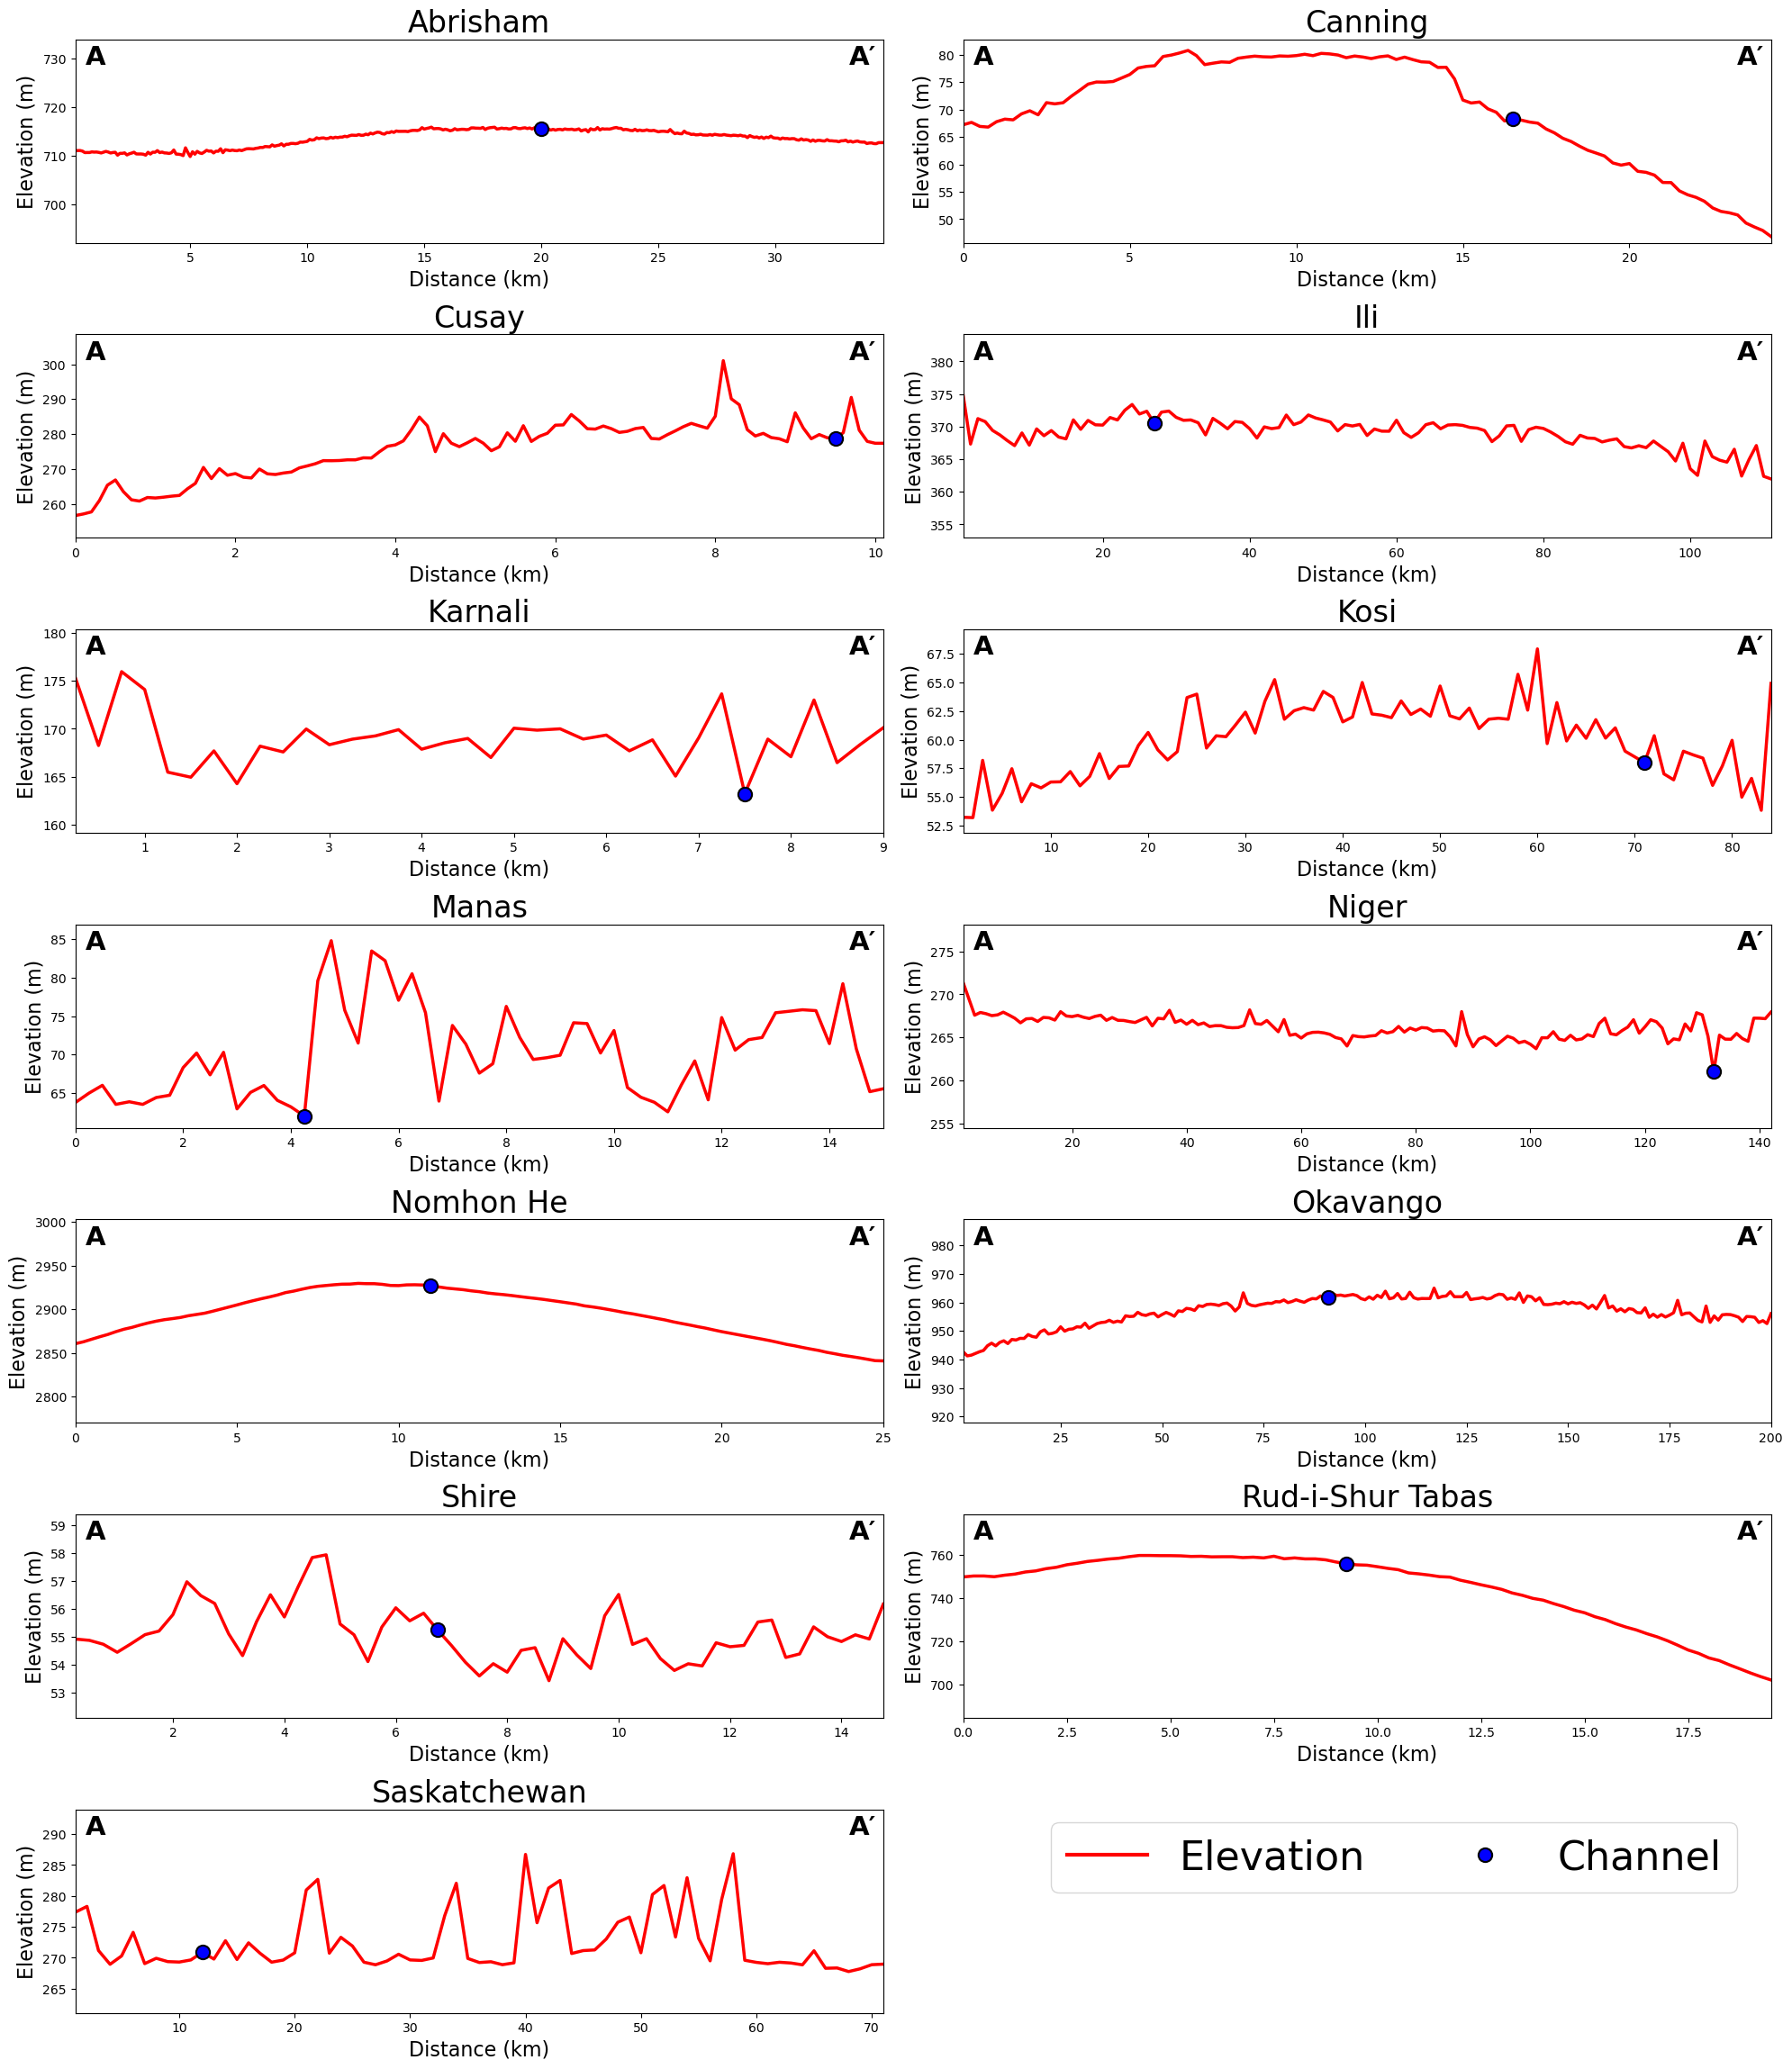

In [4]:
# -------------------------------
# Get unique fans from df3
fan_list = df3['Fan'].unique()
channel_circle_size = 120  # same as cross-section
channel_edgewidth = 1.5

# -------------------------------
# Cross-section label offsets
x_offset = 0.025  # relative x-position for A/A′
y_fixed = 0.975  # relative y-position for A/A′
label_size = 21  # font size for A/A′

# -------------------------------
# Create 2-column subplot grid (rows adjust automatically)
ncols = 2
nrows = int(np.ceil(len(fan_list) / ncols))
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(20, 3.4 * nrows))
axes = axes.flatten()

# -------------------------------
# Loop through each fan and plot
for i, fan_name in enumerate(fan_list):
    ax = axes[i]
    
    # Filter and sort
    df_fan = df3[df3['Fan'] == fan_name].copy().sort_values("Distance")
    df_fan['Elevation'] = df_fan['Elevation'].interpolate(method='linear')
    
    # Red line: cross-section elevation
    ax.plot(df_fan['Distance'], df_fan['Elevation'], color='red', linewidth=2.5, zorder=1)

    # Blue circles: channel points (match cross-section style)
    df_channel = df_fan[df_fan['Channel'] == "Channel"]
    ax.scatter(df_channel['Distance'], df_channel['Elevation'],
               color='blue', s=channel_circle_size,
               edgecolor='black', linewidths=channel_edgewidth,
               marker='o', zorder=2)
    
    # Axis formatting
    ymin, ymax = df_fan['Elevation'].min(), df_fan['Elevation'].max()
    ax.set_ylim(0.975 * ymin, 1.025 * ymax)
    ax.margins(x=0)  #  horizontal whitespace

    ax.set_title(fan_name, fontsize=24)
    ax.set_xlabel('Distance (km)', fontsize=16)
    ax.set_ylabel('Elevation (m)', fontsize=16)
    ax.tick_params(axis='both', labelsize=10)
    ax.grid(False)
    
    # Add A and A′ labels inside plot frame
    ax.text(x_offset, y_fixed, "A", fontsize=label_size, fontweight='bold',
            ha='center', va='top', transform=ax.transAxes)
    ax.text(1 - x_offset, y_fixed, "A′", fontsize=label_size, fontweight='bold',
            ha='center', va='top', transform=ax.transAxes)

# Hide unused subplots
for j in range(len(fan_list), len(axes)):
    axes[j].axis('off')

# -------------------------------
# Global legend using proxy artists (match marker style)
legend_handles = [
    Line2D([0], [0], color='red', linewidth=3, label='Elevation'),
    Line2D([0], [0], marker='o', color='blue', markerfacecolor='blue',
           markeredgecolor='black', markersize=np.sqrt(channel_circle_size),
           linestyle='None', label='Channel', markeredgewidth=channel_edgewidth)
]

fig.legend(handles=legend_handles,
           loc='lower left', fontsize=32, ncol=2, bbox_to_anchor=(0.575, .075))

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


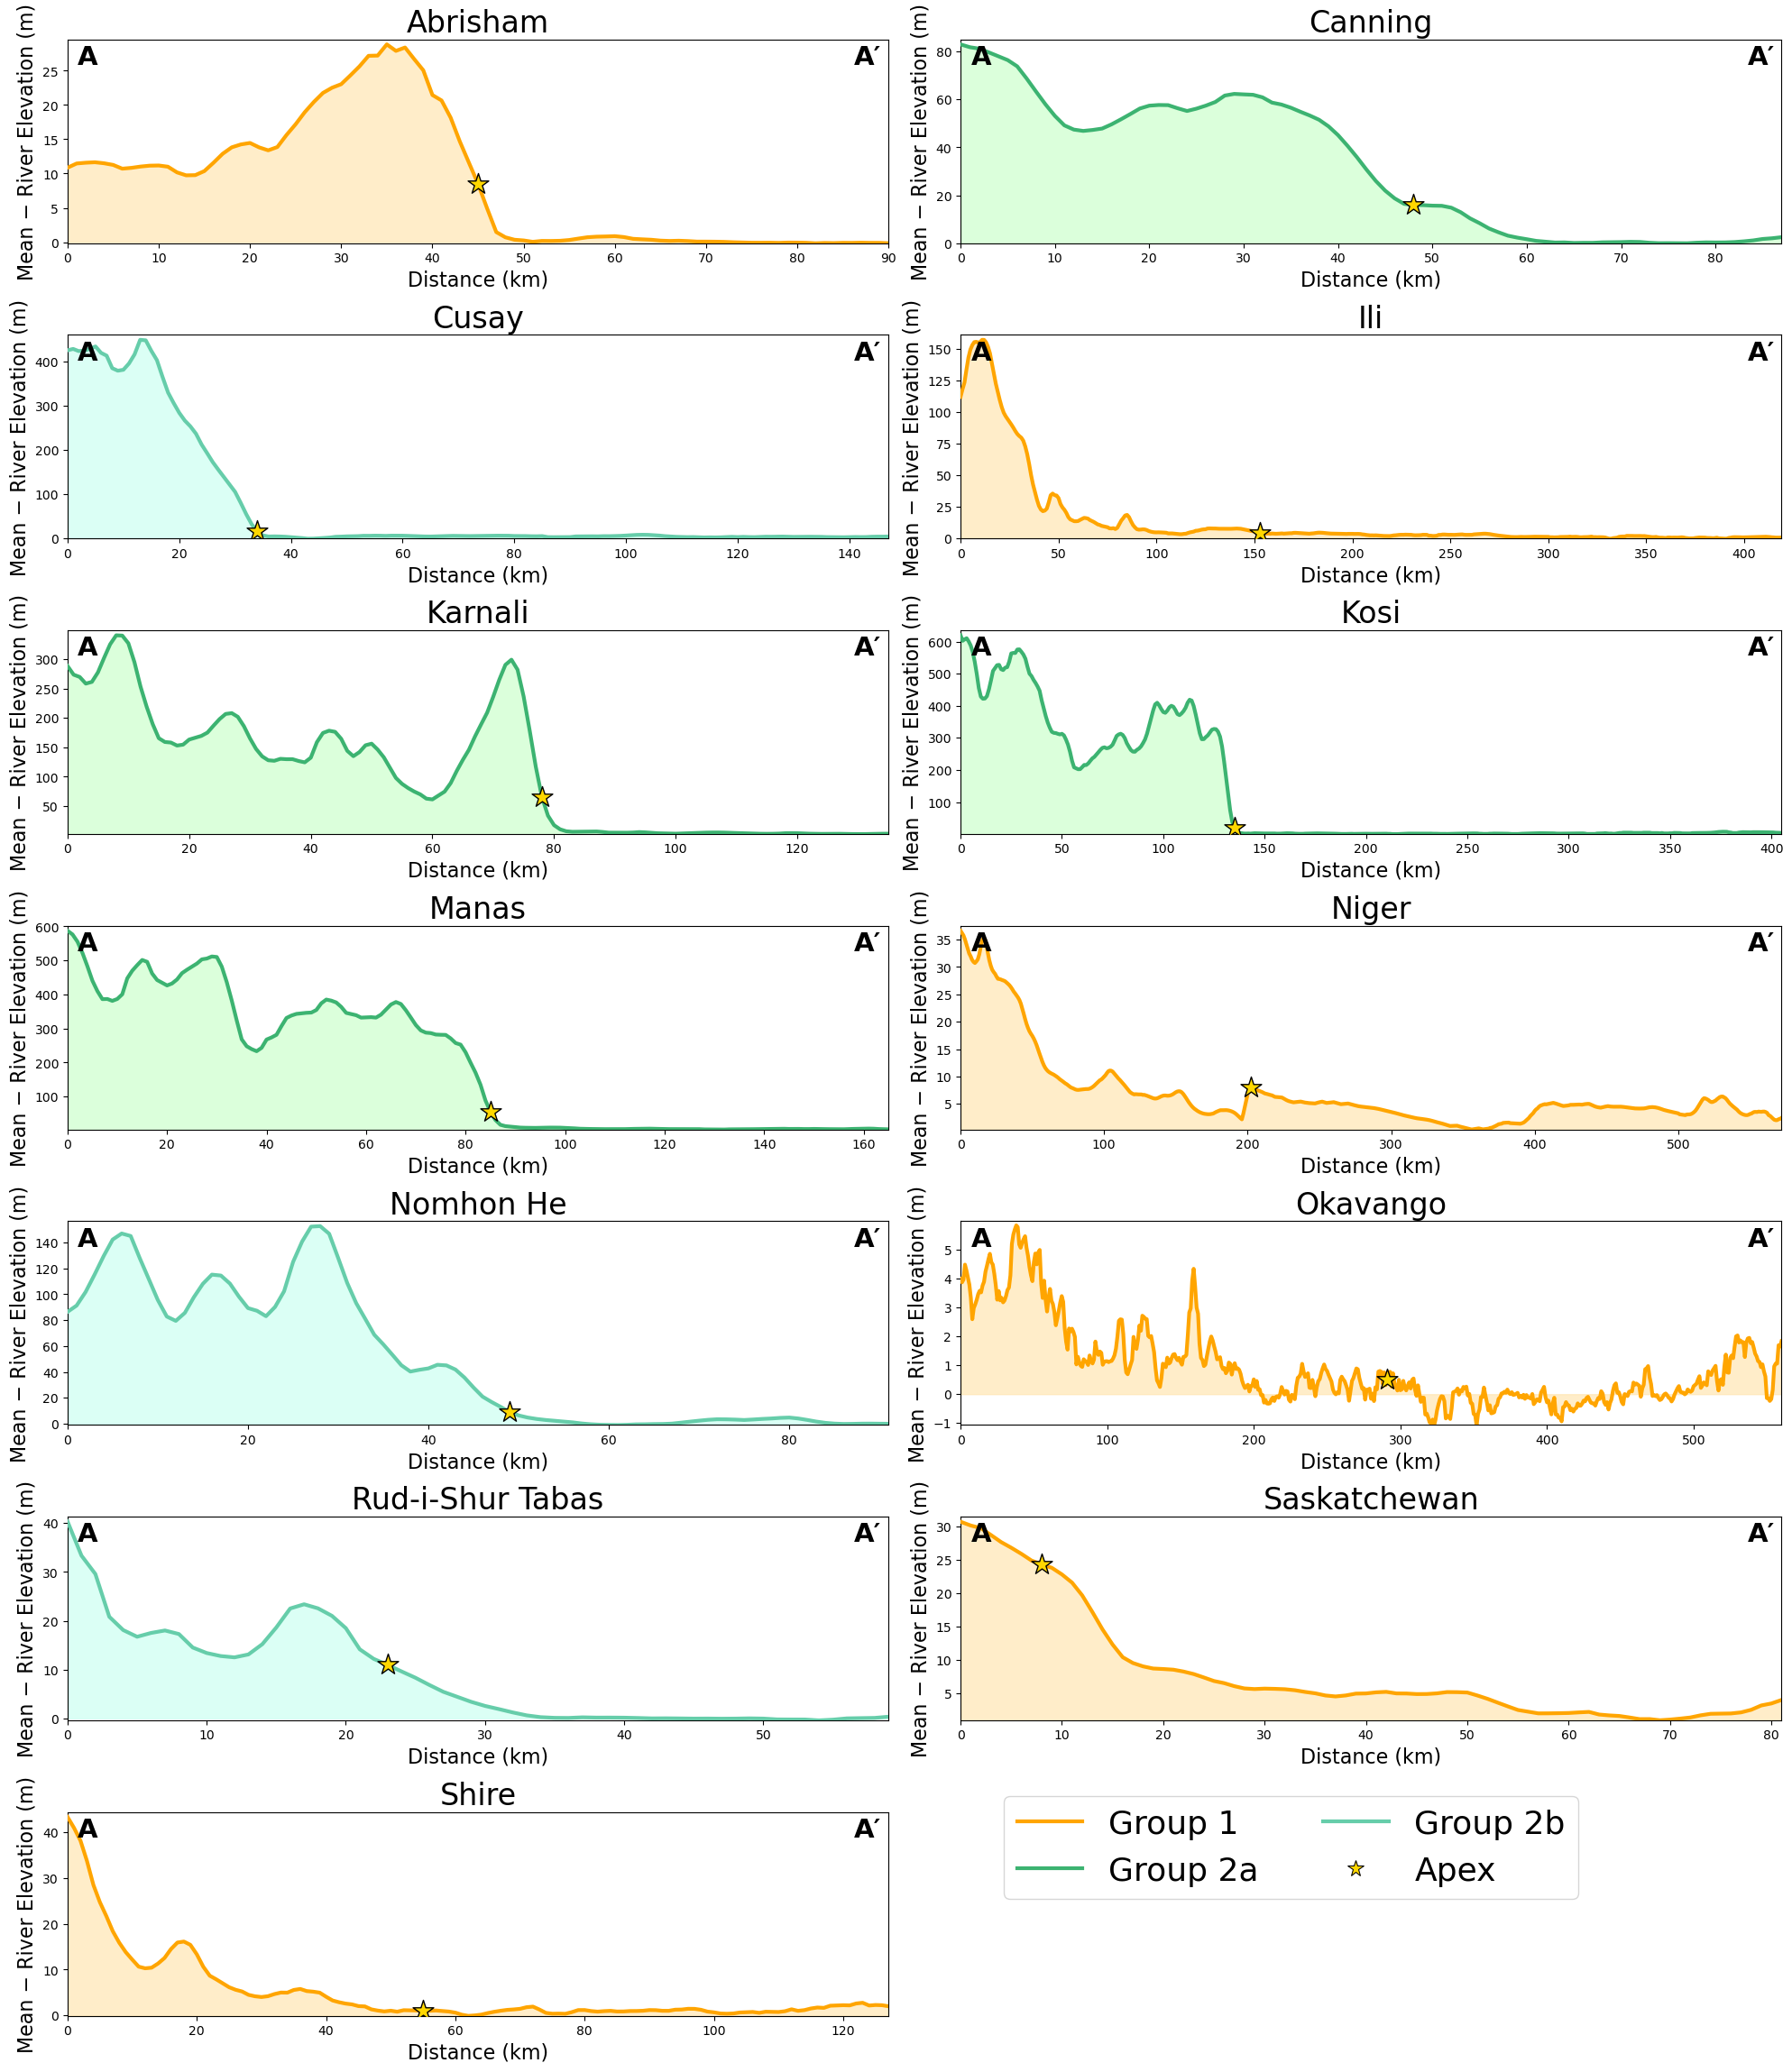

In [37]:
# ---------------------------------------------------------
# Define fan groups (for color + shading)
# ---------------------------------------------------------
group1_fans = ["Abrisham", "Ili", "Niger", "Okavango", "Saskatchewan", "Shire"]
group2a_fans = ["Canning", "Karnali", "Manas", "Kosi"]
group2b_fans = ["Nomhon He", "Rud-i-Shur Tabas", "Cusay"]

# Assign line and shading colors
fan_colors = {
    **{f: ("orange", (1.0, 0.9, 0.7)) for f in group1_fans},          # pale orange fill
    **{f: ("mediumseagreen", (0.8, 1.0, 0.8)) for f in group2a_fans}, # pale green fill
    **{f: ("mediumaquamarine", (0.8, 1.0, 0.95)) for f in group2b_fans}, # pale aqua fill
}

# ---------------------------------------------------------
# Layout
# ---------------------------------------------------------
fan_list = sorted(df2["Fan"].unique())  # alphabetical
ncols = 2
nrows = int(np.ceil(len(fan_list) / ncols))
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(20, 3.4 * nrows))
axes = axes.flatten()

window_size = 5
apex_marker_size = 180
label_size = 21
x_offset = 0.025
y_fixed = 0.975

# ---------------------------------------------------------
# Loop through fans
# ---------------------------------------------------------
for i, fan_name in enumerate(fan_list):
    ax = axes[i]
    df_fan = df2[df2["Fan"] == fan_name].copy().sort_values("Distance")

    if df_fan.empty:
        ax.text(0.5, 0.5, f"{fan_name}\n(no data)", ha="center", va="center")
        ax.axis("off")
        continue

    # Interpolate missing data
    df_fan["Mean Elevation"] = df_fan["Mean Elevation"].interpolate(method="linear")
    df_fan["River Elevation"] = df_fan["River Elevation"].interpolate(method="linear")

    # Compute Mean − River difference
    df_fan["Topo_River_Diff"] = df_fan["Mean Elevation"] - df_fan["River Elevation"]
    df_fan["Diff_smooth"] = df_fan["Topo_River_Diff"].rolling(
        window=window_size, center=True, min_periods=1
    ).mean()

    # Colors
    line_color, shade_color = fan_colors.get(fan_name, ("gray", "whitesmoke"))

    # Plot main line
    ax.plot(df_fan["Distance"], df_fan["Diff_smooth"],
            color=line_color, linewidth=3, zorder=3)

    # Shading *under* the curve only
    ax.fill_between(df_fan["Distance"], df_fan["Diff_smooth"], 0,
                    color=shade_color, alpha=0.7, zorder=2)

     # Apex markers
    apex_rows = df_fan[df_fan["Apex"].isin(["Apex", "Both"])]
    if not apex_rows.empty:
        ax.scatter(
            apex_rows["Distance"],
            apex_rows["Diff_smooth"], 
            color="gold",
            edgecolor="black",
            marker="*",
            s=300,
            linewidths=1.0,
            zorder=10
        )

    # Axis formatting
    ymin, ymax = df_fan["Diff_smooth"].min(), df_fan["Diff_smooth"].max()
    ax.set_ylim(0.975 * ymin, 1.025 * ymax)
    ax.margins(x=0)
    ax.set_title(fan_name, fontsize=24)
    ax.set_xlabel("Distance (km)", fontsize=16)
    ax.set_ylabel("Mean − River Elevation (m)", fontsize=16)
    ax.tick_params(axis="both", labelsize=10)
    ax.grid(False)

    # A/A′ labels
    ax.text(x_offset, y_fixed, "A", fontsize=label_size, fontweight="bold",
            ha="center", va="top", transform=ax.transAxes)
    ax.text(1 - x_offset, y_fixed, "A′", fontsize=label_size, fontweight="bold",
            ha="center", va="top", transform=ax.transAxes)

# ---------------------------------------------------------
# Hide unused panels
# ---------------------------------------------------------
for j in range(len(fan_list), len(axes)):
    axes[j].axis("off")

# ---------------------------------------------------------
# Global legend
# ---------------------------------------------------------
legend_handles = [
    Line2D([0], [0], color="orange", linewidth=3, label="Group 1"),
    Line2D([0], [0], color="mediumseagreen", linewidth=3, label="Group 2a"),
    Line2D([0], [0], color="mediumaquamarine", linewidth=3, label="Group 2b"),
    Line2D([0], [0], marker="*", color="gold", markerfacecolor="gold",
           markeredgecolor="black", markersize=np.sqrt(apex_marker_size),
           linestyle="None", label="Apex", markeredgewidth=0.75)
]

fig.legend(handles=legend_handles,
           loc="lower left", fontsize=26, ncol=2, bbox_to_anchor=(0.55, 0.075))

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()
